In [42]:
# importar bibliotecas
import pandas as pd
import matplotlib.pyplot as plt

# carregar os dados
df = pd.read_excel("/Users/samuelbucco/Documents/SCTec/Análise de Dados/Etapa Profissionalizar/Mod 1 - Modelagem de Dados/turma-visualizacao-de-dados/alunos/samuel_bucco/semana_04/base_rh.xlsx")

# exibir as primeiras e últimas linhas do dataframe
print(df.head().to_string(index=False))
print()
print(df.tail().to_string(index=False))

 ID_Funcionario                Nome Departamento       Cargo  Salario Data_Admissao Genero  Idade Estado_Civil  Status
              1         Julia Nunes    Logística Coordenador  9088.34    13/08/2024      F     43     Solteiro Inativo
              2  Sr. Gustavo Duarte           TI     Gerente  8155.98    29/04/2017      F     59     Solteiro Inativo
              3 Srta. Mariana Cunha           RH Coordenador 14027.93    11/12/2024      F     27   Divorciado   Ativo
              4  Ana Sophia da Cruz     Produção     Técnico  6647.97    16/06/2019      M     50       Casado Inativo
              5   Dr. Nicolas Pinto     Produção     Gerente  8730.19    29/03/2019      F     62       Casado Inativo

 ID_Funcionario               Nome Departamento    Cargo  Salario Data_Admissao Genero  Idade Estado_Civil  Status
            996     Matheus Aragão   Financeiro Analista 11389.03    06/05/2022      F     26        Viúvo   Ativo
            997       Ryan Martins   Financeiro Analist

In [43]:
# converter a coluna "Data de Admissão" para o tipo datetime
df["Data_Admissao"] = pd.to_datetime(df["Data_Admissao"], format='%d/%m/%Y', errors="coerce")

# extrair o ano de admissão para uma nova coluna
df["Ano_Admissao"] = df["Data_Admissao"].dt.year

print(df.dtypes.to_string())
print()
print(df[["Data_Admissao", "Ano_Admissao"]].head().to_string(index=False))

ID_Funcionario             int64
Nome                         str
Departamento                 str
Cargo                        str
Salario                  float64
Data_Admissao     datetime64[us]
Genero                       str
Idade                      int64
Estado_Civil                 str
Status                       str
Ano_Admissao               int32

Data_Admissao  Ano_Admissao
   2024-08-13          2024
   2017-04-29          2017
   2024-12-11          2024
   2019-06-16          2019
   2019-03-29          2019


In [44]:
# agrupar os dados por departamento e cargo

agrupado = df.groupby(["Departamento", "Cargo"])["ID_Funcionario"].count()

print(agrupado.to_string())

Departamento  Cargo      
Financeiro    Analista       40
              Assistente     30
              Coordenador    37
              Gerente        44
              Técnico        38
Logística     Analista       29
              Assistente     38
              Coordenador    38
              Gerente        33
              Técnico        18
Produção      Analista       22
              Assistente     41
              Coordenador    40
              Gerente        43
              Técnico        36
RH            Analista       32
              Assistente     35
              Coordenador    44
              Gerente        30
              Técnico        25
TI            Analista       31
              Assistente     25
              Coordenador    28
              Gerente        31
              Técnico        32
Vendas        Analista       24
              Assistente     30
              Coordenador    38
              Gerente        40
              Técnico        28


In [45]:
# agrupar por ano de admissao e contar admissões por ano e filtrar entre os anos de 2020 a 2024 usando query()

admissoes_ano = df.groupby("Ano_Admissao")["ID_Funcionario"].count().reset_index()
admissoes_ano = admissoes_ano.query("2020 <= Ano_Admissao <= 2024")

print(
    admissoes_ano
    .rename(columns={"ID_Funcionario": "Total_Admissoes"})
    .to_string(index=False)
)

 Ano_Admissao  Total_Admissoes
         2020               94
         2021               94
         2022              108
         2023              106
         2024              113


In [46]:
# criar uma tabela de metas de headcount por departamento com `pd.DataFrame` e fazer `merge left` com o total por departamento. Identificar se a meta foi atingida por departameto e verificar qual departamento atingiu a meta

headcount_real = (
    df.groupby("Departamento")
    .size()
    .reset_index(name="Headcount_Real")
    .sort_values("Departamento")
)

print(headcount_real.to_string(index=False))

# tabela de metas de headcount por departamento
metas = pd.DataFrame({
    "Departamento": ["Financeiro", "RH", "TI", "Vendas", "Produção", "Logística"],
    "Meta_Headcount": [180, 150, 200, 220, 300, 130]
})

print(f"\nTabela de metas de headcount por departamento:")
print(metas.to_string(index=False))

# merge left para juntar o headcount real com as metas
comparativo = pd.merge(headcount_real, metas, on="Departamento", how="left")
print(f"\nComparativo de headcount real e metas:")
print(comparativo.to_string(index=False))

# identificar se a meta foi atingida por departamento
comparativo["Diferença"] = comparativo["Headcount_Real"] - comparativo["Meta_Headcount"]
comparativo["Meta_Atingida"] = comparativo["Diferença"].apply(lambda x: "Sim" if x >= 0 else "Não")
print(f"\nComparativo com indicação de meta atingida:")
print(comparativo.to_string(index=False))


Departamento  Headcount_Real
  Financeiro             189
   Logística             156
    Produção             182
          RH             166
          TI             147
      Vendas             160

Tabela de metas de headcount por departamento:
Departamento  Meta_Headcount
  Financeiro             180
          RH             150
          TI             200
      Vendas             220
    Produção             300
   Logística             130

Comparativo de headcount real e metas:
Departamento  Headcount_Real  Meta_Headcount
  Financeiro             189             180
   Logística             156             130
    Produção             182             300
          RH             166             150
          TI             147             200
      Vendas             160             220

Comparativo com indicação de meta atingida:
Departamento  Headcount_Real  Meta_Headcount  Diferença Meta_Atingida
  Financeiro             189             180          9           Sim
   Log

In [60]:
# criar um pivot table de salario medio por departamento e genero e calcular a dirença entre mulheres e homens

pivot_salario = df.pivot_table(values="Salario", index="Departamento", columns="Genero", aggfunc="mean").round(2)

diferenca_salario = pivot_salario["F"] - pivot_salario["M"]

print(f"\nSalário médio por departamento e gênero:")
for depto in pivot_salario.index:
    print(f"  {depto:12s}: Feminino R$ {pivot_salario.loc[depto, 'F']:,.2f} | Masculino R$ {pivot_salario.loc[depto, 'M']:,.2f}")

print(f"\nDiferença salarial (Feminino - Masculino) por departamento:")
for depto in diferenca_salario.index:
    print(f"  {depto:12s}: R$ {diferenca_salario[depto]:,.2f}")



Salário médio por departamento e gênero:
  Financeiro  : Feminino R$ 8,467.26 | Masculino R$ 8,208.56
  Logística   : Feminino R$ 8,843.49 | Masculino R$ 8,944.41
  Produção    : Feminino R$ 8,797.64 | Masculino R$ 9,118.66
  RH          : Feminino R$ 9,009.20 | Masculino R$ 8,546.06
  TI          : Feminino R$ 8,107.01 | Masculino R$ 8,177.38
  Vendas      : Feminino R$ 8,926.64 | Masculino R$ 7,751.59

Diferença salarial (Feminino - Masculino) por departamento:
  Financeiro  : R$ 258.70
  Logística   : R$ -100.92
  Produção    : R$ -321.02
  RH          : R$ 463.14
  TI          : R$ -70.37
  Vendas      : R$ 1,175.05


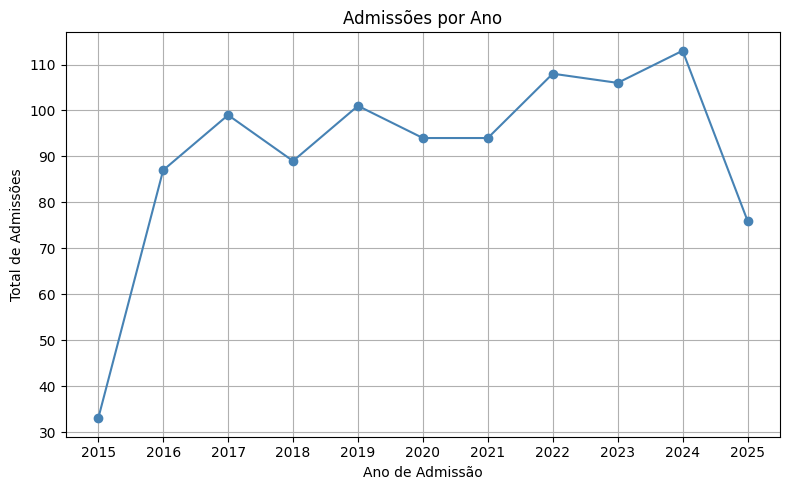

In [58]:
#plotar admissões por ano com plt.plot

admissoes_ano_plot = df.groupby("Ano_Admissao")["ID_Funcionario"].count().reset_index().rename(columns={"ID_Funcionario": "Total_Admissoes"})

plt.figure(figsize=(8, 5))
plt.plot(admissoes_ano_plot["Ano_Admissao"], admissoes_ano_plot["Total_Admissoes"], marker="o", linestyle="-", color="steelblue")
plt.title("Admissões por Ano")
plt.xlabel("Ano de Admissão")
plt.ylabel("Total de Admissões")
plt.xticks(admissoes_ano_plot["Ano_Admissao"])
plt.grid()
plt.tight_layout()
plt.show()

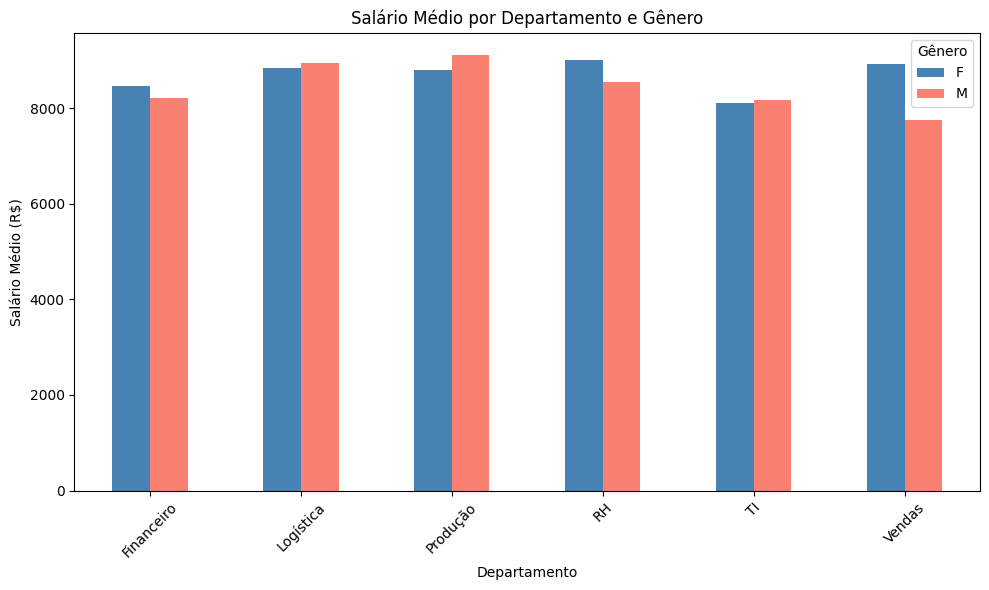

In [59]:
# Plote o pivot_table de salário médio por gênero com pivot.plot(kind="bar")

pivot_salario.plot(kind="bar", figsize=(10, 6), color=["steelblue", "salmon"])
plt.title("Salário Médio por Departamento e Gênero")
plt.xlabel("Departamento")
plt.ylabel("Salário Médio (R$)")
plt.xticks(rotation=45)
plt.legend(title="Gênero")
plt.tight_layout()
plt.show()